<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/PC08_MultiOmics_CCA_jNMF_SNF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PC08 — Multi-Omics Integration: CCA / jNMF / SNF Concepts

Compare early integration with latent/shared representations and patient-similarity fusion. The uploaded framework highlights CCA, jNMF and SNF as complementary integration strategies. fileciteturn0file0L324-L350

In [1]:
# @title Colab setup
!pip -q install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels lifelines networkx umap-learn openpyxl requests

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.1 MB/s eta 0:00:00
Environment ready.


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
X = np.random.normal(size=(30,20))  # RNA features
Y = np.random.normal(size=(30,10))  # methylation/protein features
X=StandardScaler().fit_transform(X); Y=StandardScaler().fit_transform(Y)
cca=CCA(n_components=3)
Xc,Yc=cca.fit_transform(X,Y)
print("Canonical correlations:", [np.corrcoef(Xc[:,i],Yc[:,i])[0,1] for i in range(3)])


Canonical correlations: [np.float64(0.9996509161986531), np.float64(0.9999352581872721), np.float64(0.9770734987657704)]


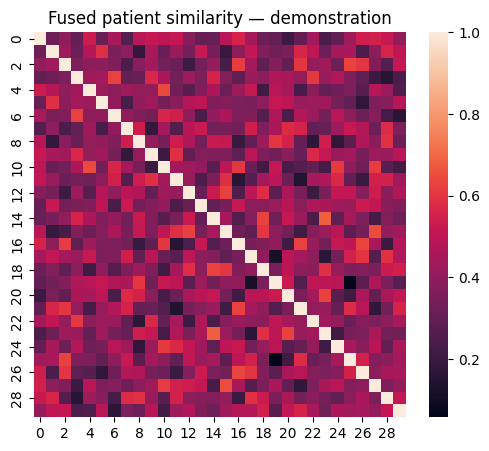

In [3]:
# Simple similarity-network fusion demonstration
from sklearn.metrics.pairwise import cosine_similarity
def affinity(A):
    S=cosine_similarity(A)
    S=(S-S.min())/(S.max()-S.min()+1e-9)
    np.fill_diagonal(S,1)
    return S
S1,S2=affinity(X),affinity(Y)
fused=(S1+S2)/2
plt.figure(figsize=(6,5)); sns.heatmap(fused); plt.title("Fused patient similarity — demonstration"); plt.show()


### Publication note
For the final study, use validated implementations of SNF/jNMF/MOFA and document feature selection, scaling, missingness and patient matching before integration.